# 완주런 — 잔차 제약 확정 실험 (저장 O · 재현 O)

**목적:** 잔차 s=0.3 잠정결과를 **확정**으로 올리기. plain CUT과 잔차CUT(0.5)을 **둘 다 끝까지 학습 + 디스크 저장** 후 480장 재평가.

- 커널 `trellis` → Restart Kernel → Run All
- **체크포인트 자동 저장**: `SAVE_EVERY` epoch마다 `latest`, 종료 시 `final` → 커널 죽어도 모델 안 잃음
- 학습 2개 × 35ep ≈ **각 1.5~2시간** (총 3~4h). 빨리 볼 땐 셀0의 `N_EPOCHS`를 줄이기(예: 5)
- 커널이 중간에 죽으면: 학습 셀 건너뛰고 **평가 셀만** 실행 → 디스크 `final`에서 자동 로드
- 잔차는 **학습·추론 동일 scale(0.5)** 로 통일 (사후 스윕 없이 깔끔한 비교)


## 0. 환경 + 설정 + 로더

In [1]:
import os, sys, time, glob
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
ROOT = os.path.expanduser("~/geoit_sr_refiner")
CUT  = os.path.join(ROOT, "refiners/cut_src")
os.chdir(CUT); sys.path.insert(0, CUT)
for p in (ROOT, os.path.join(ROOT, "team_aiduo")):
    if p not in sys.path: sys.path.append(p)
DEV = "cuda"

# ===== 설정 =====
RES_SCALE  = 0.5    # 잔차 학습·추론 공통 scale
N_EPOCHS   = 25     # (빨리 보려면 5로)
N_DECAY    = 10     # (빨리 보려면 0으로)
SAVE_EVERY = 5      # 몇 epoch마다 latest 저장
DR = os.path.join(ROOT, "refiners/data/refine_hat")

def load01(p):
    im = np.asarray(Image.open(p).convert("RGB")).astype(np.float32)/255.0
    return torch.from_numpy(im.transpose(2,0,1)).unsqueeze(0).float()
def save01(t, p):
    a = (t.detach().cpu().clamp(0,1).numpy().transpose(1,2,0)*255).round().astype("uint8")
    Image.fromarray(a).save(p)
def load_G(ckpt):
    from models import networks
    net = networks.define_G(3,3,64,"resnet_9blocks","instance",False,"xavier",0.02,False,False,[0])
    sd = torch.load(ckpt, map_location=DEV)
    (net.module if hasattr(net,"module") else net).load_state_dict(sd)
    net.eval(); return net
print("device:", torch.cuda.get_device_name(0), "| RES_SCALE:", RES_SCALE, "| epochs:", N_EPOCHS+N_DECAY)


device: NVIDIA GB10 | RES_SCALE: 0.5 | epochs: 35


## 1. 데이터 확인

  trainA: 420장
  trainB: 420장
  testA: 60장
  testB: 60장


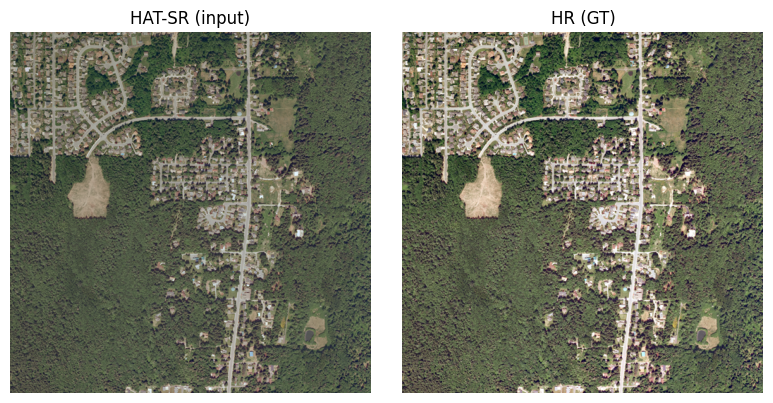

In [2]:
for s in ["trainA","trainB","testA","testB"]:
    print(f"  {s}: {len(os.listdir(os.path.join(DR,s)))}장")
a = sorted(glob.glob(DR+"/testA/*.png"))[0]
fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(Image.open(a)); ax[0].set_title("HAT-SR (input)"); ax[0].axis("off")
ax[1].imshow(Image.open(a.replace("testA","testB"))); ax[1].set_title("HR (GT)"); ax[1].axis("off")
plt.tight_layout(); plt.show()


## 2. 학습 함수 (저장 로직 포함)

In [3]:
def train_cut(name, model_name, res_scale=None):
    argv = ["train.py","--dataroot",DR,"--name",name,"--model",model_name,"--CUT_mode","CUT",
            "--display_id","0","--gpu_ids","0","--batch_size","1",
            "--n_epochs",str(N_EPOCHS),"--n_epochs_decay",str(N_DECAY),
            "--load_size","512","--crop_size","256","--print_freq","200"]
    if res_scale is not None: argv += ["--res_scale", str(res_scale)]
    sys.argv = argv
    from options.train_options import TrainOptions
    from data import create_dataset
    from models import create_model
    opt = TrainOptions().parse(); opt.num_threads = 0
    dataset = create_dataset(opt); model = create_model(opt)
    total = opt.n_epochs + opt.n_epochs_decay
    print(f"\n[{name}] {len(dataset)}장 · {total} epoch (model={model_name}, res_scale={res_scale})\n")
    t0 = time.time(); step = 0
    for epoch in range(opt.epoch_count, total + 1):
        for i, data in enumerate(dataset):
            if epoch == opt.epoch_count and i == 0:
                model.data_dependent_initialize(data); model.setup(opt); model.parallelize()
            model.set_input(data); model.optimize_parameters(); step += 1
            if step % 100 == 0:
                L = model.get_current_losses()
                print(f"  ep{epoch} step{step:>5}  G_GAN {L['G_GAN']:.3f}  NCE {L['NCE']:.3f}  ({time.time()-t0:.0f}s)")
        if epoch % SAVE_EVERY == 0 or epoch == total:
            model.save_networks("latest")
            print(f"  --- ep{epoch} 저장(latest) ({time.time()-t0:.0f}s) ---")
    model.save_networks("final")
    print(f"[{name}] 완료·저장 → checkpoints/{name}/final_net_G.pth  ({time.time()-t0:.0f}s)")
    del model, dataset; torch.cuda.empty_cache()
print("train_cut 준비됨")


train_cut 준비됨


## 3. plain CUT 완주 학습 (저장)
비교 기준용 정상 학습된 plain CUT. loss 관찰.

In [4]:
train_cut("cut_plain_full", "cut", res_scale=None)

----------------- Options ---------------
                 CUT_mode: CUT                           
               batch_size: 1                             
                    beta1: 0.5                           
                    beta2: 0.999                         
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: /home/bh8483/geoit_sr_refiner/refiners/data/refine_hat	[default: placeholder]
             dataset_mode: unaligned                     
                direction: AtoB                          
              display_env: main                          
             display_freq: 400                           
               display_id: 0                             	[default: None]
            display_ncols: 4                             
             display_port: 8097                          
           display_server

/home/bh8483/geoit_sr_refiner/refiners/cut_src/models/networks.py:569: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  patch_id = torch.tensor(patch_id, dtype=torch.long, device=feat.device)


---------- Networks initialized -------------
[Network G] Total number of parameters : 11.378 M
[Network F] Total number of parameters : 0.560 M
[Network D] Total number of parameters : 2.765 M
-----------------------------------------------


/home/bh8483/geoit_sr_refiner/refiners/cut_src/models/networks.py:569: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  patch_id = torch.tensor(patch_id, dtype=torch.long, device=feat.device)
/home/bh8483/geoit_sr_refiner/refiners/cut_src/models/base_model.py:161: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  errors_ret[name] = float(getattr(self, 'loss_' + name))  # float(...) works for both scalar tensor and float number


  ep1 step  100  G_GAN 0.266  NCE 4.075  (25s)
  ep1 step  200  G_GAN 0.745  NCE 3.963  (43s)
  ep1 step  300  G_GAN 0.427  NCE 3.402  (62s)
  ep1 step  400  G_GAN 0.253  NCE 3.294  (80s)
  ep2 step  500  G_GAN 0.271  NCE 2.450  (99s)
  ep2 step  600  G_GAN 0.311  NCE 2.589  (117s)
  ep2 step  700  G_GAN 0.409  NCE 2.437  (136s)
  ep2 step  800  G_GAN 0.340  NCE 2.212  (154s)
  ep3 step  900  G_GAN 0.346  NCE 2.582  (173s)
  ep3 step 1000  G_GAN 0.354  NCE 2.153  (191s)
  ep3 step 1100  G_GAN 0.278  NCE 1.768  (210s)
  ep3 step 1200  G_GAN 0.400  NCE 1.932  (228s)
  ep4 step 1300  G_GAN 0.378  NCE 1.463  (247s)
  ep4 step 1400  G_GAN 0.297  NCE 1.817  (265s)
  ep4 step 1500  G_GAN 0.365  NCE 1.764  (284s)
  ep4 step 1600  G_GAN 0.311  NCE 1.719  (302s)
  ep5 step 1700  G_GAN 0.444  NCE 1.550  (321s)
  ep5 step 1800  G_GAN 0.524  NCE 1.570  (340s)
  ep5 step 1900  G_GAN 0.318  NCE 1.689  (358s)
  ep5 step 2000  G_GAN 0.471  NCE 1.658  (377s)
  ep5 step 2100  G_GAN 0.462  NCE 1.606  (395

## 4. 잔차 CUT(0.5) 완주 학습 (저장)
학습·추론 동일 scale=0.5.

In [5]:
train_cut("cut_res05_full", "cutres", res_scale=RES_SCALE)

----------------- Options ---------------
                 CUT_mode: CUT                           
               batch_size: 1                             
                    beta1: 0.5                           
                    beta2: 0.999                         
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: /home/bh8483/geoit_sr_refiner/refiners/data/refine_hat	[default: placeholder]
             dataset_mode: unaligned                     
                direction: AtoB                          
              display_env: main                          
             display_freq: 400                           
               display_id: 0                             	[default: None]
            display_ncols: 4                             
             display_port: 8097                          
           display_server

## 5. 480장 확정 평가 (디스크 로드)
커널이 죽었어도 이 셀만 단독 실행 가능 (final 체크포인트 자동 로드).

In [6]:
from cycleGen_model import load_cyclegan_model
G_cyc   = load_cyclegan_model(os.path.join(ROOT,"weights/best_G_AB.pth"), device=DEV)
G_plain = load_G(os.path.join(CUT,"checkpoints/cut_plain_full/final_net_G.pth"))
G_res   = load_G(os.path.join(CUT,"checkpoints/cut_res05_full/final_net_G.pth"))
def refine_plain(G,x):
    with torch.no_grad(): return ((G(x*2-1)+1)/2).clamp(0,1)
def refine_res(G,x,s):
    r=x*2-1
    with torch.no_grad(): g=G(r); return ((r+s*(g-r)).clamp(-1,1)+1).mul(0.5).clamp(0,1)

allA = sorted(glob.glob(DR+"/trainA/*.png")) + sorted(glob.glob(DR+"/testA/*.png"))
test_names = set(os.path.basename(p) for p in glob.glob(DR+"/testA/*.png"))
base = os.path.join(ROOT, "runs/eval_run")
dirs = {k: os.path.join(base,k) for k in ["sr_hat","cyclegan","plain_cut","cut_res05"]}
hr_ref = os.path.join(base,"hr_ref")
for dd in list(dirs.values())+[hr_ref]: os.makedirs(dd, exist_ok=True)
print(f"{len(allA)}장 처리 중 (잔차 s={RES_SCALE})...")
for j, ta in enumerate(allA):
    name=os.path.basename(ta); x=load01(ta).to(DEV)
    save01(x[0], os.path.join(dirs["sr_hat"], name))
    save01(refine_plain(G_cyc, x)[0], os.path.join(dirs["cyclegan"], name))
    save01(refine_plain(G_plain, x)[0], os.path.join(dirs["plain_cut"], name))
    save01(refine_res(G_res, x, RES_SCALE)[0], os.path.join(dirs["cut_res05"], name))
    save01(load01(ta.replace("/trainA/","/trainB/").replace("/testA/","/testB/"))[0], os.path.join(hr_ref, name))
    if (j+1)%100==0: print(f"  {j+1}/{len(allA)}")
print("처리 완료 · 지표 계산...")
from skimage.metrics import structural_similarity as ssim
import lpips as _L, pyiqa
from pytorch_fid.fid_score import calculate_fid_given_paths
lp=_L.LPIPS(net="alex").to(DEV); niqe=pyiqa.create_metric("niqe", device=DEV)
def psnr(a,b):
    m=float(((a-b)**2).mean()); return 99.0 if m==0 else 10*np.log10(1/m)
rows={}
for cond,dd in dirs.items():
    ps,ss,lps=[],[],[]
    for name in sorted(test_names):
        out=load01(os.path.join(dd,name)); hr=load01(os.path.join(hr_ref,name))
        a=out[0].numpy().transpose(1,2,0); b=hr[0].numpy().transpose(1,2,0)
        ps.append(psnr(a,b)); ss.append(ssim(a,b,channel_axis=2,data_range=1.0))
        with torch.no_grad(): lps.append(float(lp(out.to(DEV)*2-1, hr.to(DEV)*2-1).mean()))
    nqs=[float(niqe(os.path.join(dd,n))) for n in os.listdir(dd)]
    fid=calculate_fid_given_paths([dd,hr_ref],batch_size=50,device=DEV,dims=2048)
    rows[cond]=(np.mean(ps),np.mean(ss),np.mean(lps),fid,np.mean(nqs))
print(f"\n===== 완주런 확정 (HAT 입력, 잔차 s={RES_SCALE}, 480장) =====")
print(f"{'조건':12s} | {'PSNR up':>8} {'SSIM up':>8} {'LPIPS dn':>9} | {'FID dn':>8} {'NIQE dn':>8}")
print("-"*64)
for k in ["sr_hat","cyclegan","plain_cut","cut_res05"]:
    p,s,l,f,n=rows[k]; print(f"{k:12s} | {p:8.3f} {s:8.4f} {l:9.4f} | {f:8.3f} {n:8.3f}")
print("\n확정 판정: cut_res05가 (a) cyclegan을 SSIM/LPIPS/FID로 이기고 (b) plain_cut보다 SSIM/LPIPS 좋으면 → 잔차 제약 효과 확정.")


✅ [CycleGen] 가중치 로드 완료: best_G_AB.pth
480장 처리 중 (잔차 s=0.5)...
  100/480
  200/480
  300/480
  400/480
처리 완료 · 지표 계산...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/bh8483/miniforge3/envs/trellis/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


/home/bh8483/miniforge3/envs/trellis/lib/python3.10/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bh8483/miniforge3/envs/trellis/lib/python3.10/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 10/10 [00:03<00:00,  2.64it/s]



===== 완주런 확정 (HAT 입력, 잔차 s=0.5, 480장) =====
조건           |  PSNR up  SSIM up  LPIPS dn |   FID dn  NIQE dn
----------------------------------------------------------------
sr_hat       |   14.771   0.5037    0.5444 |  216.267   12.165
cyclegan     |   13.739   0.3636    0.6059 |  198.579    5.949
plain_cut    |   14.391   0.3314    0.6317 |  172.084    7.177
cut_res05    |    9.774   0.2880    0.4853 |  176.547    5.624

확정 판정: cut_res05가 (a) cyclegan을 SSIM/LPIPS/FID로 이기고 (b) plain_cut보다 SSIM/LPIPS 좋으면 → 잔차 제약 효과 확정.


In [7]:
# ===== 저장된 cut_res05 추론 스윕 (480장 FID, CycleGAN 198.6 / plain CUT 171.8 직접 비교) =====
import os, glob, numpy as np, torch
G_res = load_G(os.path.join(CUT, "checkpoints/cut_res05_full/final_net_G.pth"))
def refine_s(G,x,s):
    r=x*2-1
    with torch.no_grad(): g=G(r); return ((r+s*(g-r)).clamp(-1,1)+1).mul(0.5).clamp(0,1)

S_LIST=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
allA = sorted(glob.glob(DR+"/trainA/*.png")) + sorted(glob.glob(DR+"/testA/*.png"))
test_names = set(os.path.basename(p) for p in glob.glob(DR+"/testA/*.png"))
hr_ref = os.path.join(ROOT,"runs/eval_run/hr_ref")   # 확정런과 동일 기준
assert os.path.isdir(hr_ref) and len(os.listdir(hr_ref))>=len(allA), "먼저 셀7(평가) 실행해 hr_ref 생성 필요"

from skimage.metrics import structural_similarity as ssim
import lpips as _L, pyiqa
from pytorch_fid.fid_score import calculate_fid_given_paths
lp=_L.LPIPS(net="alex").to(DEV); niqe=pyiqa.create_metric("niqe",device=DEV)
def psnr(a,b):
    m=float(((a-b)**2).mean()); return 99.0 if m==0 else 10*np.log10(1/m)

rows=[]; base=os.path.join(ROOT,"runs/sweep_res05")
for s in S_LIST:
    dd=os.path.join(base,f"s{int(round(s*100)):03d}"); os.makedirs(dd,exist_ok=True)
    for ta in allA:
        x=load01(ta).to(DEV); save01(refine_s(G_res,x,s)[0], os.path.join(dd,os.path.basename(ta)))
    ps,ss,lps=[],[],[]
    for name in sorted(test_names):
        out=load01(os.path.join(dd,name)); hr=load01(os.path.join(hr_ref,name))
        a=out[0].numpy().transpose(1,2,0); b=hr[0].numpy().transpose(1,2,0)
        ps.append(psnr(a,b)); ss.append(ssim(a,b,channel_axis=2,data_range=1.0))
        with torch.no_grad(): lps.append(float(lp(out.to(DEV)*2-1,hr.to(DEV)*2-1).mean()))
    nqs=[float(niqe(os.path.join(dd,n))) for n in os.listdir(dd)]
    fid=calculate_fid_given_paths([dd,hr_ref],batch_size=50,device=DEV,dims=2048)
    rows.append((s,np.mean(ps),np.mean(ss),np.mean(lps),fid,np.mean(nqs)))
    print(f"s={s:.2f} | PSNR {np.mean(ps):6.2f} SSIM {np.mean(ss):.3f} LPIPS {np.mean(lps):.3f} FID {fid:7.2f} NIQE {np.mean(nqs):.3f}")

print("\n  s   | PSNR up SSIM up LPIPS dn | FID dn  NIQE dn   (저장 cut_res05, 480 FID)")
print("-"*62)
for s,p,ss_,l,f,n in rows:
    mark=" <- FID<199!" if f<198.6 else ""
    print(f" {s:.2f} | {p:6.2f} {ss_:7.3f} {l:8.3f} | {f:7.2f} {n:7.3f}{mark}")
print("\n기준: CycleGAN 198.6 / plain CUT 171.8 (동일 480장). FID<199 나오는 s가 있으면 잔차 생존.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/bh8483/miniforge3/envs/trellis/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


100%|██████████| 10/10 [00:03<00:00,  2.65it/s]


s=0.00 | PSNR  14.77 SSIM 0.504 LPIPS 0.544 FID  216.27 NIQE 12.165


100%|██████████| 10/10 [00:03<00:00,  2.69it/s]


s=0.10 | PSNR  13.77 SSIM 0.473 LPIPS 0.443 FID  190.30 NIQE 5.677


...

s=0.30 | PSNR  11.38 SSIM 0.383 LPIPS 0.428 FID  177.76 NIQE 5.290


100%|██████████| 10/10 [00:03<00:00,  2.70it/s]


s=0.40 | PSNR  10.50 SSIM 0.336 LPIPS 0.452 FID  175.63 NIQE 5.477


100%|██████████| 10/10 [00:03<00:00,  2.73it/s]


s=0.50 | PSNR   9.77 SSIM 0.288 LPIPS 0.485 FID  176.55 NIQE 5.624

  s   | PSNR up SSIM up LPIPS dn | FID dn  NIQE dn   (저장 cut_res05, 480 FID)
--------------------------------------------------------------
 0.00 |  14.77   0.504    0.544 |  216.27  12.165
 0.10 |  13.77   0.473    0.443 |  190.30   5.677 <- FID<199!
 0.20 |  12.49   0.430    0.416 |  183.76   5.184 <- FID<199!
 0.30 |  11.38   0.383    0.428 |  177.76   5.290 <- FID<199!
 0.40 |  10.50   0.336    0.452 |  175.63   5.477 <- FID<199!
 0.50 |   9.77   0.288    0.485 |  176.55   5.624 <- FID<199!

기준: CycleGAN 198.6 / plain CUT 171.8 (동일 480장). FID<199 나오는 s가 있으면 잔차 생존.


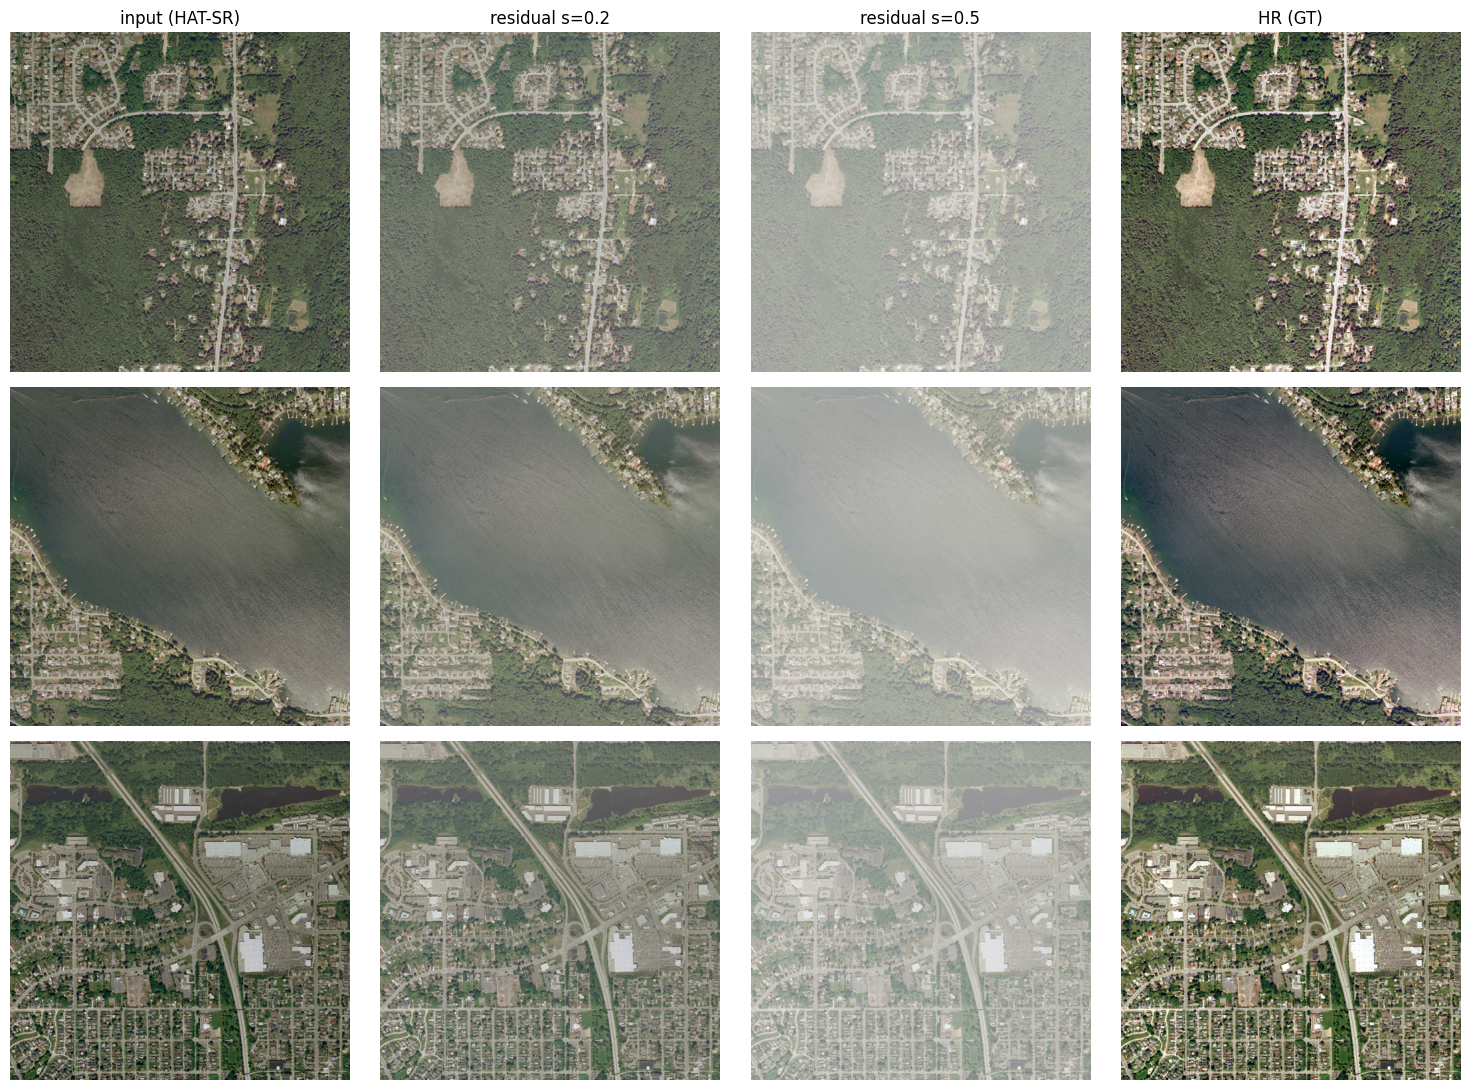

In [8]:
import matplotlib.pyplot as plt, glob, os
G_res = load_G(os.path.join(CUT,"checkpoints/cut_res05_full/final_net_G.pth"))
def refine_s(G,x,s):
    r=x*2-1
    with torch.no_grad(): g=G(r); return ((r+s*(g-r)).clamp(-1,1)+1).mul(0.5).clamp(0,1)
tests=sorted(glob.glob(DR+"/testA/*.png"))[:3]
cols=["input (HAT-SR)","residual s=0.2","residual s=0.5","HR (GT)"]
fig,ax=plt.subplots(3,4,figsize=(15,11))
for r,ta in enumerate(tests):
    x=load01(ta).to(DEV)
    imgs=[x[0].cpu(), refine_s(G_res,x,0.2)[0].cpu(), refine_s(G_res,x,0.5)[0].cpu(),
          load01(ta.replace("testA","testB"))[0]]
    for c,(im,t) in enumerate(zip(imgs,cols)):
        ax[r,c].imshow(im.numpy().transpose(1,2,0)); ax[r,c].axis("off")
        if r==0: ax[r,c].set_title(t)
plt.tight_layout(); plt.show()

✅ [CycleGen] 가중치 로드 완료: best_G_AB.pth


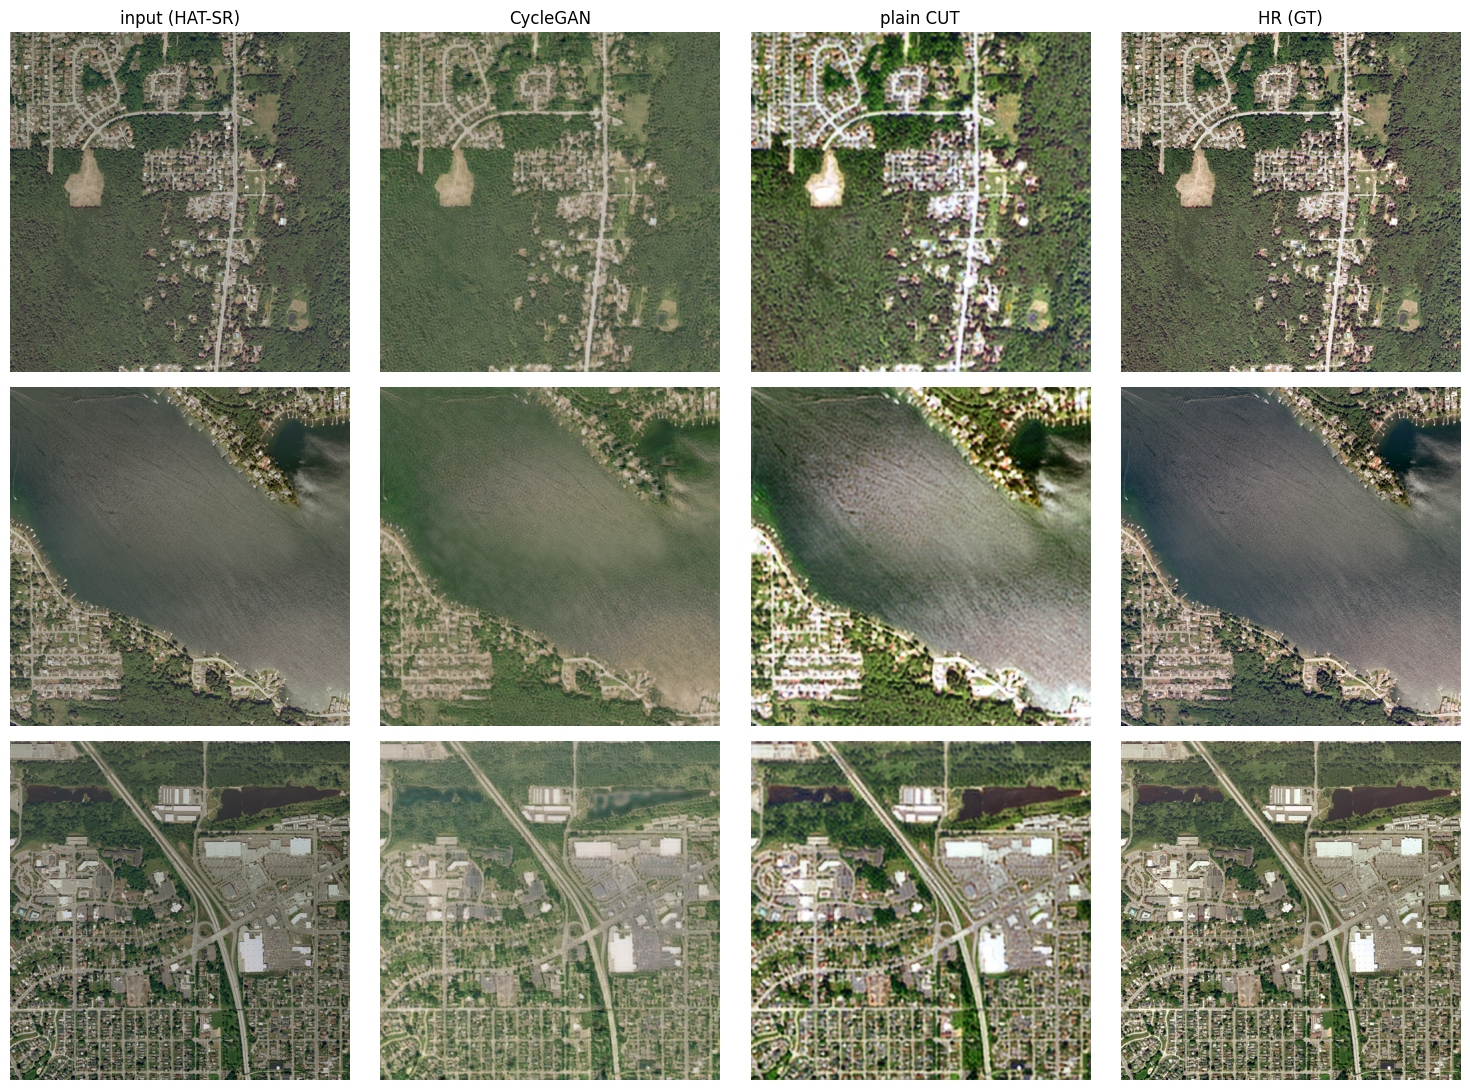

In [9]:
import matplotlib.pyplot as plt, glob, os
G_plain = load_G(os.path.join(CUT,"checkpoints/cut_plain_full/final_net_G.pth"))
from cycleGen_model import load_cyclegan_model
G_cyc = load_cyclegan_model(os.path.join(ROOT,"weights/best_G_AB.pth"), device=DEV)
def refine_plain(G,x):
    with torch.no_grad(): return ((G(x*2-1)+1)/2).clamp(0,1)
tests=sorted(glob.glob(DR+"/testA/*.png"))[:3]
cols=["input (HAT-SR)","CycleGAN","plain CUT","HR (GT)"]
fig,ax=plt.subplots(3,4,figsize=(15,11))
for r,ta in enumerate(tests):
    x=load01(ta).to(DEV)
    imgs=[x[0].cpu(), refine_plain(G_cyc,x)[0].cpu(), refine_plain(G_plain,x)[0].cpu(),
          load01(ta.replace("testA","testB"))[0]]
    for c,(im,t) in enumerate(zip(imgs,cols)):
        ax[r,c].imshow(im.numpy().transpose(1,2,0)); ax[r,c].axis("off")
        if r==0: ax[r,c].set_title(t)
plt.tight_layout(); plt.show()

## 해석
- **cut_res05 vs cyclegan**: SSIM·LPIPS·FID 우위면 unpaired 개선 확정.
- **cut_res05 vs plain_cut**: 잔차 제약 자체가 plain CUT을 개선하는지(구조 보존).
- 이번엔 모델이 디스크에 저장돼 **재현·팀공유 가능**. 확정되면 STATUS/노션을 "확정"으로 승격.
- 사후 스윕이 필요하면 저장된 `cut_res05_full/final`로 추론 s만 스윕(별도 셀).
